# **Feature Engineering** 🧩

Este notebook tem como objetivo construir o conjunto de dados utilizado para prever a **recompra de produtos pelos usuários**.

O problema de negócio pode ser definido como:

> Dado um usuário e um produto, queremos estimar se esse produto será recomprado no próximo pedido.

Para isso, serão criadas features em três níveis principais:

- **Produto**: popularidade e taxa histórica de recompra;
- **Usuário**: frequência, recorrência e padrões temporais de compra;
- **Interação usuário-produto**: histórico específico de relação entre cada usuário e cada produto.

Ao final, essas informações serão consolidadas em um dataset único para uso nas próximas etapas de modelagem.


In [2]:
# =========================================
# 📚 IMPORTAÇÃO DAS BIBLIOTECAS
# =========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [3]:
# =========================================
# 📂 CARREGAMENTO DOS DADOS
# =========================================

DATA_PATH = Path("../data/raw")

orders = pd.read_csv(DATA_PATH / "orders.csv")
products = pd.read_csv(DATA_PATH / "products.csv")
departments = pd.read_csv(DATA_PATH / "departments.csv")
aisles = pd.read_csv(DATA_PATH / "aisles.csv")

order_products_prior = pd.read_csv(
    DATA_PATH / "order_products__prior.csv"
)

order_products_train = pd.read_csv(
    DATA_PATH / "order_products__train.csv"
)

In [4]:
# =========================================
# 📊 DISTRIBUIÇÃO DOS PEDIDOS
# =========================================

orders["eval_set"].value_counts()

eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

In [5]:
# =========================================
# 🏗️ PEDIDOS DE TREINAMENTO
# =========================================

train_orders = orders[
    orders["eval_set"] == "train"
]

print(f"Shape: {train_orders.shape}")

train_orders.head()

Shape: (131209, 7)


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
10,1187899,1,train,11,4,8,14.0
25,1492625,2,train,15,1,11,30.0
49,2196797,5,train,5,0,11,6.0
74,525192,7,train,21,2,11,6.0
78,880375,8,train,4,1,14,10.0


In [6]:
# =========================================
# 🎯 DISTRIBUIÇÃO DA VARIÁVEL ALVO
# =========================================

target_distribution = (
    order_products_train["reordered"]
    .value_counts(normalize=True)
    .sort_index()
)

display(target_distribution)

reordered
0    0.401406
1    0.598594
Name: proportion, dtype: float64

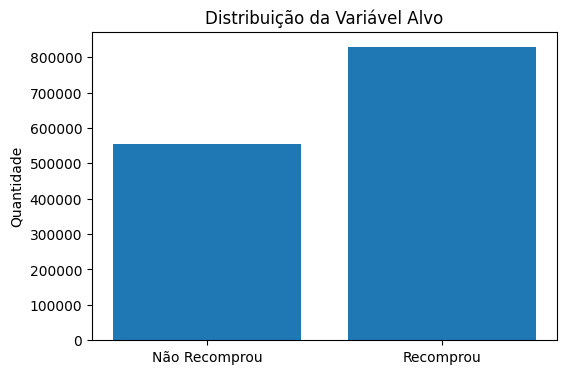

In [7]:
# =========================================
# 📊 VISUALIZAÇÃO DA VARIÁVEL ALVO
# =========================================

target_counts = (
    order_products_train["reordered"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(6,4))

plt.bar(
    ["Não Recomprou", "Recomprou"],
    target_counts.values
)

plt.title("Distribuição da Variável Alvo")
plt.ylabel("Quantidade")

plt.show()



## 📋 **1. Visão Geral da Base e Variável Alvo**

Nesta etapa, será realizada uma verificação inicial dos dados carregados, com foco na separação dos conjuntos `prior`, `train` e `test`, além da análise da variável alvo `reordered`.

💡 **Observação**:

A distribuição da variável alvo fornece informações importantes sobre o equilíbrio entre as classes. Caso exista predominância significativa de uma das categorias, poderão ser necessárias estratégias específicas durante a modelagem, como ajuste de métricas, balanceamento ou definição cuidadosa do threshold de decisão.


In [8]:
# =========================================
# 🛒 TOTAL DE COMPRAS POR PRODUTO
# =========================================

product_purchase_count = (
    order_products_prior
    .groupby("product_id")
    .size()
    .reset_index(name="total_purchases")
)

product_purchase_count.head()

,product_id,total_purchases
0,1,1852
1,2,90
2,3,277
3,4,329
4,5,15


In [9]:
# =========================================
# 🔁 TAXA DE RECOMPRA POR PRODUTO
# =========================================

product_reorder_rate = (
    order_products_prior
    .groupby("product_id")["reordered"]
    .mean()
    .reset_index(name="reorder_rate")
)

product_reorder_rate.head()

,product_id,reorder_rate
0,1,0.613391
1,2,0.133333
2,3,0.732852
3,4,0.446809
4,5,0.600000


In [10]:
# =========================================
# 🧩 DATASET DE FEATURES DE PRODUTO
# =========================================

product_features = (
    products
    .merge(product_purchase_count, on="product_id")
    .merge(product_reorder_rate, on="product_id")
)

product_features.head()

,product_id,product_name,aisle_id,department_id,total_purchases,reorder_rate
0,1,Chocolate Sandwich Cookies,61,19,1852,0.613391
1,2,All-Seasons Salt,104,13,90,0.133333
2,3,Robust Golden Unsweetened Oolong Tea,94,7,277,0.732852
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,329,0.446809
4,5,Green Chile Anytime Sauce,5,13,15,0.600000


## 🛒 **2. Features de Produto**

Nesta etapa, serão construídas variáveis relacionadas ao comportamento histórico de cada produto dentro da plataforma.

As principais informações consideradas são:

- quantidade total de compras do produto;
- taxa média de recompra;
- dados cadastrais do produto, como `aisle_id` e `department_id`.

💡 **Observação**:

A divisão dos dados demonstra que a maior parte dos pedidos pertence ao conjunto `prior`, utilizado para representar o histórico de compras dos usuários. O conjunto `train` contém os pedidos usados para construção do dataset supervisionado, no qual a coluna `reordered` será utilizada como variável alvo.


In [11]:
# =========================================
# 👤 TOTAL DE PEDIDOS POR USUÁRIO
# =========================================

user_total_orders = (
    orders.groupby("user_id")["order_number"]
    .max()
    .reset_index(name="total_orders")
)

user_total_orders.head()

,user_id,total_orders
0,1,11
1,2,15
2,3,13
3,4,6
4,5,5


In [12]:
# =========================================
# 📅 MÉDIA DE DIAS ENTRE PEDIDOS
# =========================================

user_avg_days_between_orders = (
    orders.groupby("user_id")["days_since_prior_order"]
    .mean()
    .reset_index(name="avg_days_between_orders")
)

user_avg_days_between_orders.head()

,user_id,avg_days_between_orders
0,1,19.000000
1,2,16.285714
2,3,12.000000
3,4,17.000000
4,5,11.500000


In [13]:
# =========================================
# ⏰ HORÁRIO MÉDIO DE COMPRA
# =========================================

user_avg_order_hour = (
    orders.groupby("user_id")["order_hour_of_day"]
    .mean()
    .reset_index(name="avg_order_hour")
)

user_avg_order_hour.head()

,user_id,avg_order_hour
0,1,10.090909
1,2,10.600000
2,3,16.307692
3,4,12.500000
4,5,15.000000


In [14]:
# =========================================
# 📊 DIA DA SEMANA MAIS FREQUENTE
# =========================================

user_favorite_day = (
    orders.groupby("user_id")["order_dow"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index(name="favorite_order_day")
)

user_favorite_day.head()

,user_id,favorite_order_day
0,1,4
1,2,1
2,3,0
3,4,4
4,5,0


In [15]:
# =========================================
# 🧩 DATASET DE FEATURES DE USUÁRIO
# =========================================

user_features = (
    user_total_orders
    .merge(user_avg_days_between_orders, on="user_id")
    .merge(user_avg_order_hour, on="user_id")
    .merge(user_favorite_day, on="user_id")
)

user_features.head()

,user_id,total_orders,avg_days_between_orders,avg_order_hour,favorite_order_day
0,1,11,19.000000,10.090909,4
1,2,15,16.285714,10.600000,1
2,3,13,12.000000,16.307692,0
3,4,6,17.000000,12.500000,4
4,5,5,11.500000,15.000000,0


## 👤 **3. Features de Usuário**

As features de usuário buscam representar hábitos individuais de compra, frequência de uso da plataforma e padrões temporais de consumo.

Essas informações ajudam o modelo a diferenciar usuários mais recorrentes, usuários com intervalos maiores entre pedidos e perfis com horários ou dias de compra mais característicos.

💡 **Observação**:

Essas variáveis complementam as características dos produtos e tornam o dataset mais rico, pois incorporam o comportamento histórico de cada usuário, não apenas informações agregadas dos itens comprados.


## 🔗 **4. Features de Interação Usuário-Produto**

As features de interação representam o relacionamento específico entre cada usuário e produto.

Essas variáveis costumam apresentar elevado poder preditivo, pois descrevem o histórico direto de compra e recompra entre um usuário e um item específico.


In [16]:
# =========================================
# 🔗 HISTÓRICO USUÁRIO-PRODUTO
# =========================================

prior_with_users = (
    order_products_prior
    .merge(
        orders[["order_id", "user_id"]],
        on="order_id"
    )
)

prior_with_users.head()

,order_id,product_id,add_to_cart_order,reordered,user_id
0,2,33120,1,1,202279
1,2,28985,2,1,202279
2,2,9327,3,0,202279
3,2,45918,4,1,202279
4,2,30035,5,0,202279


In [17]:
# =========================================
# 🔢 QUANTIDADE DE COMPRAS USUÁRIO-PRODUTO
# =========================================

user_product_purchase_count = (
    prior_with_users
    .groupby(["user_id", "product_id"])
    .size()
    .reset_index(name="user_product_purchase_count")
)

user_product_purchase_count.head()

,user_id,product_id,user_product_purchase_count
0,1,196,10
1,1,10258,9
2,1,10326,1
3,1,12427,10
4,1,13032,3


In [18]:
# =========================================
# 🔁 TAXA DE RECOMPRA USUÁRIO-PRODUTO
# =========================================

user_product_reorder_rate = (
    prior_with_users
    .groupby(["user_id", "product_id"])["reordered"]
    .mean()
    .reset_index(name="user_product_reorder_rate")
)

user_product_reorder_rate.head()

,user_id,product_id,user_product_reorder_rate
0,1,196,0.900000
1,1,10258,0.888889
2,1,10326,0.000000
3,1,12427,0.900000
4,1,13032,0.666667


In [19]:
# =========================================
# 🧩 DATASET DE FEATURES USUÁRIO-PRODUTO
# =========================================

user_product_features = (
    user_product_purchase_count
    .merge(
        user_product_reorder_rate,
        on=["user_id", "product_id"]
    )
)

user_product_features.head()

,user_id,product_id,user_product_purchase_count,user_product_reorder_rate
0,1,196,10,0.900000
1,1,10258,9,0.888889
2,1,10326,1,0.000000
3,1,12427,10,0.900000
4,1,13032,3,0.666667


## 🧩 **5. Construção do Dataset Final**

Nesta etapa, serão integradas todas as features construídas anteriormente.

O objetivo é gerar uma tabela única contendo:

- informações dos produtos;
- informações dos usuários;
- informações de interação usuário-produto;
- variável alvo `reordered`.


In [20]:
# =========================================
# 🎯 DATASET COM VARIÁVEL ALVO
# =========================================

train_data = (
    order_products_train
    .merge(
        train_orders[["order_id", "user_id"]],
        on="order_id"
    )
)

train_data.head()

,order_id,product_id,add_to_cart_order,reordered,user_id
0,1,49302,1,1,112108
1,1,11109,2,1,112108
2,1,10246,3,0,112108
3,1,49683,4,0,112108
4,1,43633,5,1,112108


In [21]:
# =========================================
# 👤 ADIÇÃO DAS FEATURES DE USUÁRIO
# =========================================

train_data = (
    train_data
    .merge(
        user_features,
        on="user_id",
        how="left"
    )
)

train_data.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,total_orders,avg_days_between_orders,avg_order_hour,favorite_order_day
0,1,49302,1,1,112108,4,10.333333,13.75,1
1,1,11109,2,1,112108,4,10.333333,13.75,1
2,1,10246,3,0,112108,4,10.333333,13.75,1
3,1,49683,4,0,112108,4,10.333333,13.75,1
4,1,43633,5,1,112108,4,10.333333,13.75,1


In [22]:
# =========================================
# 🛒 ADIÇÃO DAS FEATURES DE PRODUTO
# =========================================

train_data = (
    train_data
    .merge(
        product_features,
        on="product_id",
        how="left"
    )
)

train_data.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,total_orders,avg_days_between_orders,avg_order_hour,favorite_order_day,product_name,aisle_id,department_id,total_purchases,reorder_rate
0,1,49302,1,1,112108,4,10.333333,13.75,1,Bulgarian Yogurt,120.0,16.0,163.0,0.619632
1,1,11109,2,1,112108,4,10.333333,13.75,1,Organic 4% Milk Fat Whole Milk Cottage Cheese,108.0,16.0,4472.0,0.713775
2,1,10246,3,0,112108,4,10.333333,13.75,1,Organic Celery Hearts,83.0,4.0,23826.0,0.524553
3,1,49683,4,0,112108,4,10.333333,13.75,1,Cucumber Kirby,83.0,4.0,97315.0,0.691702
4,1,43633,5,1,112108,4,10.333333,13.75,1,Lightly Smoked Sardines in Olive Oil,95.0,15.0,653.0,0.477795


In [23]:
# =========================================
# 🔗 ADIÇÃO DAS FEATURES DE INTERAÇÃO
# =========================================

train_data = (
    train_data
    .merge(
        user_product_features,
        on=["user_id", "product_id"],
        how="left"
    )
)

train_data.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,total_orders,avg_days_between_orders,avg_order_hour,favorite_order_day,product_name,aisle_id,department_id,total_purchases,reorder_rate,user_product_purchase_count,user_product_reorder_rate
0,1,49302,1,1,112108,4,10.333333,13.75,1,Bulgarian Yogurt,120.0,16.0,163.0,0.619632,2.0,0.5
1,1,11109,2,1,112108,4,10.333333,13.75,1,Organic 4% Milk Fat Whole Milk Cottage Cheese,108.0,16.0,4472.0,0.713775,2.0,0.5
2,1,10246,3,0,112108,4,10.333333,13.75,1,Organic Celery Hearts,83.0,4.0,23826.0,0.524553,NaN,NaN
3,1,49683,4,0,112108,4,10.333333,13.75,1,Cucumber Kirby,83.0,4.0,97315.0,0.691702,NaN,NaN
4,1,43633,5,1,112108,4,10.333333,13.75,1,Lightly Smoked Sardines in Olive Oil,95.0,15.0,653.0,0.477795,2.0,0.5


In [24]:
# =========================================
# 📊 VALIDAÇÃO DO DATASET FINAL
# =========================================

print("Shape:", train_data.shape)

train_data.info()

Shape: (1384617, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1384617 entries, 0 to 1384616
Data columns (total 16 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   order_id                     1384617 non-null  int64  
 1   product_id                   1384617 non-null  int64  
 2   add_to_cart_order            1384617 non-null  int64  
 3   reordered                    1384617 non-null  int64  
 4   user_id                      1384617 non-null  int64  
 5   total_orders                 1384617 non-null  int64  
 6   avg_days_between_orders      1384617 non-null  float64
 7   avg_order_hour               1384617 non-null  float64
 8   favorite_order_day           1384617 non-null  int64  
 9   product_name                 1384608 non-null  object 
 10  aisle_id                     1384608 non-null  float64
 11  department_id                1384608 non-null  float64
 12  total_purchases      

In [25]:
# =========================================
# 🔍 ANÁLISE DE VALORES AUSENTES
# =========================================

missing = (
    train_data.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

user_product_reorder_rate      555793
user_product_purchase_count    555793
aisle_id                            9
total_purchases                     9
department_id                       9
product_name                        9
reorder_rate                        9
dtype: int64

💡 **Observação**:

O dataset final consolida informações históricas dos usuários, características dos produtos e métricas de interação usuário-produto. Essas variáveis servirão como entrada para os modelos de Machine Learning nas próximas etapas do projeto.


In [26]:
# =========================================
# 🧹 TRATAMENTO DE VALORES AUSENTES
# =========================================

train_data["user_product_purchase_count"] = (
    train_data["user_product_purchase_count"]
    .fillna(0)
)

train_data["user_product_reorder_rate"] = (
    train_data["user_product_reorder_rate"]
    .fillna(0)
)

In [27]:
# =========================================
# 🧾 REMOÇÃO DE REGISTROS INCONSISTENTES
# =========================================
train_data = train_data.dropna(
    subset=[
        "product_name",
        "aisle_id",
        "department_id"
    ]
)

## 🧹 **6. Tratamento de Valores Ausentes**

Nesta etapa, os valores ausentes serão tratados de acordo com sua origem dentro do processo de engenharia de atributos.

💡 **Observação**:

A análise dos valores ausentes revelou que a maior parte dos registros nulos está associada às variáveis de interação usuário-produto. Esse comportamento é esperado, pois alguns produtos presentes no conjunto de treino podem não ter histórico anterior de compra por determinado usuário.

Nesses casos, os valores foram preenchidos com `0`, indicando ausência de histórico prévio. Já registros sem informações essenciais de produto foram removidos para preservar a consistência da base final.


## 💾 **7. Exportação da Base Processada**

Após a construção e limpeza do dataset final, a base será salva em formato `.parquet`, permitindo melhor desempenho de leitura e escrita nas próximas etapas do projeto.


In [28]:
# =========================================
# 💾 EXPORTAÇÃO DO DATASET PROCESSADO
# =========================================
train_data.to_parquet(
    "../data/processed/train_dataset.parquet",
    index=False
)


OSError: Cannot save file into a non-existent directory: '..\data\processed'

## 📌 Conclusão do Feature Engineering

A etapa de engenharia de atributos transformou os dados brutos de pedidos, produtos e usuários em um dataset estruturado para modelagem preditiva.

Foram criadas variáveis em nível de produto, usuário e interação usuário-produto, permitindo representar tanto padrões gerais de consumo quanto comportamentos específicos de recompra.

Com a base final exportada, o projeto passa a ter uma estrutura adequada para treinamento, avaliação e comparação dos modelos de Machine Learning.
